In [1]:
!pip install Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.2 MB/s eta 0:00:00


In [2]:
!pip install openpyxl

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import preprocessing, model_selection, naive_bayes, svm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import re

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_excel("/content/drive/MyDrive/CyberBullying/v1/dataset.xlsx", engine='openpyxl')

In [6]:
df.drop(['Unnamed: 6', 'Unnamed: 7'], axis=1, inplace=True)

In [7]:
print(f'Bentuk dari dataset : {df.shape}')
print('Gambaran dari dataset :')
df.head().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

Bentuk dari dataset : (650, 6)
Gambaran dari dataset :


,No.,Nama Instagram,Komentar,Kategori,Tanggal Posting,Nama Akun IG Artis/Selebgram
0,1,@delliananda,"""Kaka tidur yaa, udah pagi, gaboleh capek2""",Non-bullying,14 Oktober 2019,@isyanasarasvati
1,2,@fenninbl,"""makan nasi padang aja begini badannya""",Non-bullying,14 Oktober 2019,@isyanasarasvati
2,3,@abdurahmanshq,"""yang aku suka dari dia adalah selalu cukur jembut sebelum manggung""",Bullying,14 Oktober 2019,@isyanasarasvati
3,4,@najla.yoo,"""Hai kak Isyana aku ngefans banget sama kak Isyana.aku paling suka lagu kak Isyana itu lagu tetap didalam jiwa""",Non-bullying,14 Oktober 2019,@isyanasarasvati
4,5,@dessy_______,"""Manusia apa bidadari sih herann deh cantik terus 😌♥️""",Non-bullying,14 Oktober 2019,@isyanasarasvati


In [8]:
def remove_punctuation_and_number(text):
    '''a function for removing punctuation'''
    import string
    import re
    for sp in string.punctuation:
        text = text.replace(sp, " ")
    text = re.sub(r"\d+","",text)
    return text.replace('/\s\s+/g', ' ')
df['Komentar'] = df['Komentar'].apply(remove_punctuation_and_number)

In [9]:
sw = ["bacod","cokk","anjirrr","anjeng","anjir","anying","anjay","kolot","tolol"]
def stopwords(text):
    '''a function for removing the stopword'''
    import re
    text = [word.lower() for word in text.split()]
    for word in text:
        for stop in sw:
            if word==stop:
                text.remove(word)
    text = " ".join(text)
    text = re.sub(r'(.+?)\1+', r'\1',text)
    return text
df['Komentar'] = df['Komentar'].apply(stopwords)

In [10]:
df['Komentar'].head(10).to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,Komentar
0,ka tidur ya udah pagi gaboleh capek
1,makan nasi padang aja begini badanya
2,yang aku suka dari dia adalah selalu cukur jembut sebelum mangung
3,hai kak isyana aku ngefans banget sama kak isyana aku paling suka lagu kak isyana itu lagu tetap didalam jiwa
4,manusia apa bidari sih heran deh cantik terus 😌♥️
5,ayu kinanti isyan skrg berubah ya baju nya nakal
6,gemesnya isyan kayak tango berlapis cia
7,makin jelek aja anaknya padahal ibu ayahnya cakep
8,kok anaknya kayak udah tua gitu ya mukanya k tasya
9,muka anak nya ko tua banget ya gk ngemesin gk ada lucunya


In [11]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
stop_factory = StopWordRemoverFactory()
data= stop_factory.get_stop_words()
stopword = stop_factory.create_stop_word_remover()

In [12]:
df['Komentar'].head(10).to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,Komentar
0,ka tidur ya udah pagi gaboleh capek
1,makan nasi padang aja begini badanya
2,yang aku suka dari dia adalah selalu cukur jembut sebelum mangung
3,hai kak isyana aku ngefans banget sama kak isyana aku paling suka lagu kak isyana itu lagu tetap didalam jiwa
4,manusia apa bidari sih heran deh cantik terus 😌♥️
5,ayu kinanti isyan skrg berubah ya baju nya nakal
6,gemesnya isyan kayak tango berlapis cia
7,makin jelek aja anaknya padahal ibu ayahnya cakep
8,kok anaknya kayak udah tua gitu ya mukanya k tasya
9,muka anak nya ko tua banget ya gk ngemesin gk ada lucunya


In [13]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(text):
    text = [stemmer.stem(word) for word in text.split()]
    return " ".join(text)
df['Komentar'] = df['Komentar'].apply(stemming)

In [14]:
df['Komentar'].head(10).to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,Komentar
0,ka tidur ya udah pagi gaboleh capek
1,makan nasi padang aja begini bada
2,yang aku suka dari dia adalah selalu cukur jembut belum mangung
3,hai kak isyana aku ngefans banget sama kak isyana aku paling suka lagu kak isyana itu lagu tetap dalam jiwa
4,manusia apa bidari sih heran deh cantik terus
5,ayu kinanti isyan skrg ubah ya baju nya nakal
6,gemesnya isyan kayak tango lap cia
7,makin jelek aja anak padahal ibu ayah cakep
8,kok anak kayak udah tua gitu ya muka k tasya
9,muka anak nya ko tua banget ya gk ngemesin gk ada lucu


In [15]:
from wordcloud import WordCloud, STOPWORDS
Bullying= " ".join(review for review in df[df['Kategori'] == 'Bullying'].Komentar)
Non_Bullying= " ".join(review for review in df[df['Kategori'] == 'Non-bullying'].Komentar)
stopwords = set(STOPWORDS)
def plot_cloud(wordcloud):
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud)
    plt.axis("off");

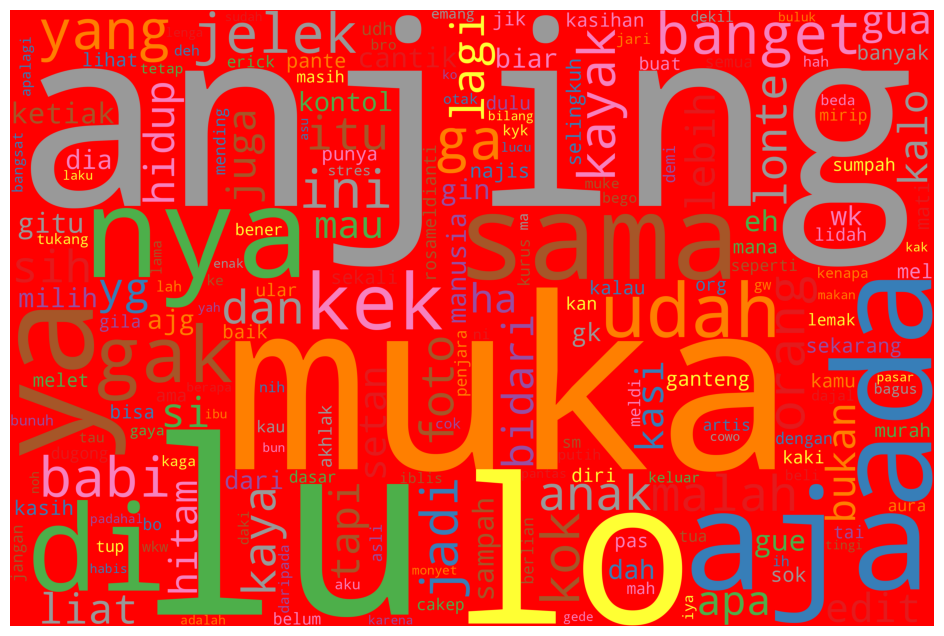

In [16]:
wordcloud1 = WordCloud(width = 3000, height = 2000, random_state=3, background_color='red', colormap='Set1', collocations=False, stopwords = STOPWORDS).generate(Bullying)
plot_cloud(wordcloud1)

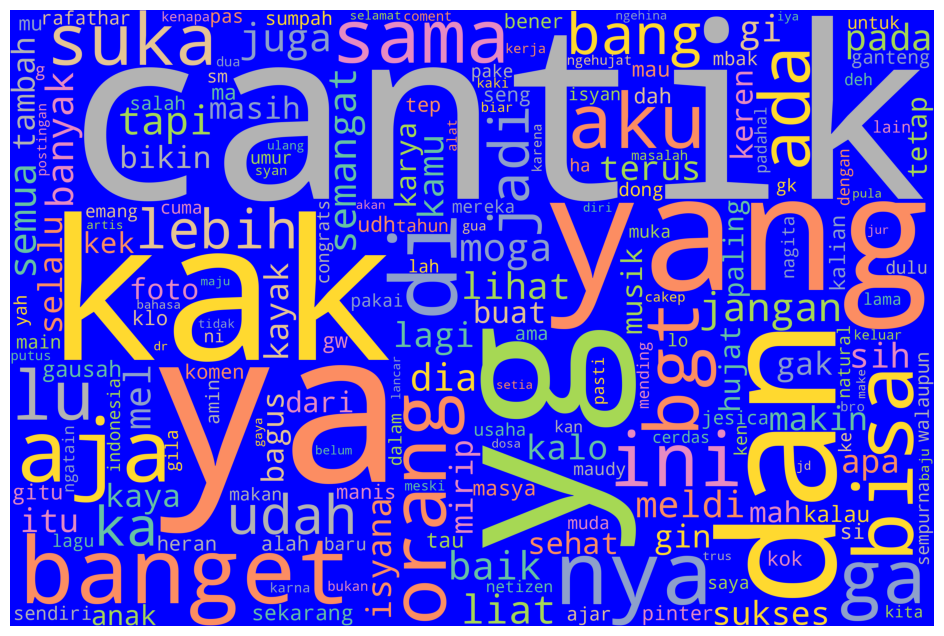

In [17]:
wordcloud2 = WordCloud(width = 3000, height = 2000, random_state=3, background_color='blue', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(Non_Bullying)
plot_cloud(wordcloud2)

In [18]:

df.Kategori.replace("Bullying", 0 , inplace = True)
df.Kategori.replace("Non-bullying", 1 , inplace = True)
df.head(10).style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,No.,Nama Instagram,Komentar,Kategori,Tanggal Posting,Nama Akun IG Artis/Selebgram
0,1,@delliananda,ka tidur ya udah pagi gaboleh capek,1,14 Oktober 2019,@isyanasarasvati
1,2,@fenninbl,makan nasi padang aja begini bada,1,14 Oktober 2019,@isyanasarasvati
2,3,@abdurahmanshq,yang aku suka dari dia adalah selalu cukur jembut belum mangung,0,14 Oktober 2019,@isyanasarasvati
3,4,@najla.yoo,hai kak isyana aku ngefans banget sama kak isyana aku paling suka lagu kak isyana itu lagu tetap dalam jiwa,1,14 Oktober 2019,@isyanasarasvati
4,5,@dessy_______,manusia apa bidari sih heran deh cantik terus,1,14 Oktober 2019,@isyanasarasvati
5,6,@e.fril,ayu kinanti isyan skrg ubah ya baju nya nakal,0,14 Oktober 2019,@isyanasarasvati
6,7,@bahasa.bayi.planet,gemesnya isyan kayak tango lap cia,1,16 September 2019,@isyanasarasvati
7,8,@khanayarudinita,makin jelek aja anak padahal ibu ayah cakep,0,22 Juni 2019,@tasyakamila
8,9,@reniaulia225,kok anak kayak udah tua gitu ya muka k tasya,0,22 Juni 2019,@tasyakamila
9,10,@nurjanah.hani,muka anak nya ko tua banget ya gk ngemesin gk ada lucu,0,22 Juni 2019,@tasyakamila


In [19]:
Train_X, Test_X, Train_Y, Test_Y = model_selection.train_test_split(df['Komentar'],df['Kategori'],test_size=0.3)

In [20]:
Test_X

616       mba isyana foto gelap gin aja aesthetic bgt ya
168    sekarang bukan muka aja yang dempul tapi ketia...
442    mending yang folow pada unfolow udeh gausah ribet
77     meldi ini lama cantik loh tingal dibenerin akh...
80     kasi editor sih ini nangung dosa banget kayak ...
                             ...                        
369    ganteng kagak bakat juga kagak kelebihanya man...
487        anjir muka lo kek kuntilanak malah sok cantik
258    eh jangan dekat sama anjing ci jesica gua lemp...
320       hidup itu jngn terlalu bos playboy amat ajg lu
408                sih gue sama org otak dangkal kek gin
Name: Komentar, Length: 195, dtype: object

In [21]:
Count_vect = CountVectorizer(max_features=5000)
Count_vect.fit(df['Komentar'])
Train_X_Count = Count_vect.transform(Train_X)
Test_X_Count = Count_vect.transform(Test_X)

In [22]:
Coba = Count_vect.transform(['kamu cantik'])
print(Coba)

  (0, 290)	1
  (0, 734)	1


In [23]:
# Naive Bayes Train_X, Test_X, Train_Y, Test_Y
Naive = naive_bayes.MultinomialNB()
Naive.fit(Train_X_Count,Train_Y)
# predict the labels on validation dataset
predictions_NB = Naive.predict(Test_X_Count)
predictions_NB_t = Naive.predict(Train_X_Count)
# Use accuracy_score function to get the accuracy
print("Naive Bayes Accuracy Score Training =",accuracy_score(predictions_NB_t, Train_Y)*100)
print("Naive Bayes Accuracy Score Testing  =",accuracy_score(predictions_NB, Test_Y)*100)

Naive Bayes Accuracy Score Training = 99.12087912087912
Naive Bayes Accuracy Score Testing  = 83.07692307692308


In [24]:
Naive.predict(Coba)

array([1])

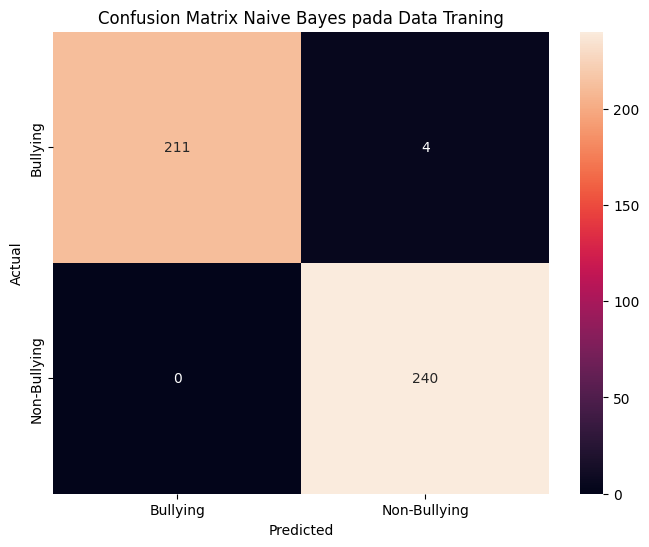

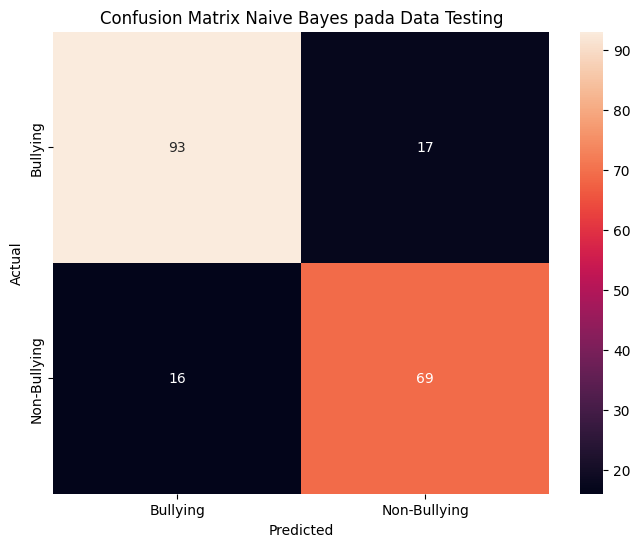

In [25]:
# Confusion matrix Naive Bayes pada data train
conf_matNB_t = confusion_matrix(Train_Y, predictions_NB_t)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(conf_matNB_t, annot=True, fmt='d',
            xticklabels=["Bullying", "Non-Bullying"], yticklabels=["Bullying", "Non-Bullying"])
plt.title('Confusion Matrix Naive Bayes pada Data Traning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# confusion matrix Naive Bayes pada data Testing
conf_matNB = confusion_matrix(Test_Y, predictions_NB)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(conf_matNB, annot=True, fmt='d',
            xticklabels=["Bullying", "Non-Bullying"], yticklabels=["Bullying", "Non-Bullying"])
plt.title('Confusion Matrix Naive Bayes pada Data Testing')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [26]:
import pickle

In [27]:
#for take model with pickle
pickle.dump(Naive, open('model.pkl', 'wb'))

In [28]:
from flask import Flask,render_template,request, current_app
from google.colab.output import eval_js

In [29]:
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://3q5hgczjjf5-496ff2e9c6d22116-5000-colab.googleusercontent.com/


In [ ]:
app = Flask(__name__,template_folder='/content/drive/MyDrive/CyberBullying/v1',static_folder='/content/drive/MyDrive/CyberBullying/v1/static')
model = pickle.load(open('model.pkl','rb'))

@app.route("/", methods=['GET', 'POST'])
def home():
    # If a form is submitted
    if request.method == "POST":

        value = request.get_json()
        value_text = value['text']
        input_convert = Count_vect.transform([value_text])
        prediction = model.predict(input_convert)
        if(prediction == 0):
          prediction = "Bully"
        else:
          prediction = "Non-Bully"
        return prediction
    else:
        prediction = ""
    return render_template('index.html',  output = prediction)

if __name__ == "__main__":
  app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:20] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:21] "GET /static/images.jpg HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:21] "GET /static/style.css HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:21] "GET /static/ajaxScroll.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:21] "GET /static/ajax.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:22] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:22] "GET /static/images.jpg HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 08:43:25] "GET /static/images.jpg HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jun/2024 09:10:39] "POST / HTTP/1.1" 200 -
INFO:werkzeug:127